<a href="https://colab.research.google.com/github/DiegoAbarza77/MachineLearning/blob/main/ExamenTransversalMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Transversal Machine Learning

# Importacion y carga

In [26]:
# Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
df = pd.read_csv('Churn_Modelling.csv')
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()



El dataset tiene 10000 filas y 14 columnas.


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Visualizacion del DataSet

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


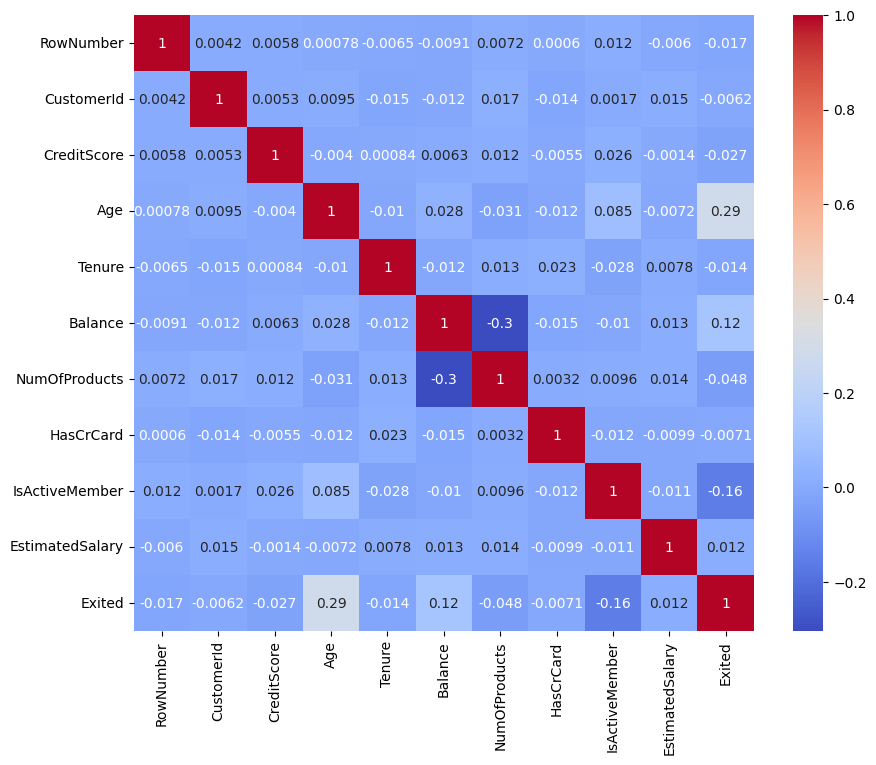

In [27]:
# Visualizar información

df.info()
df.describe()

# Análisis importante
# Clientes que abandonaron
df['Exited'].value_counts()

# Correlación
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [28]:
#Podemos ver que no hay nulos en nuestro dataset
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


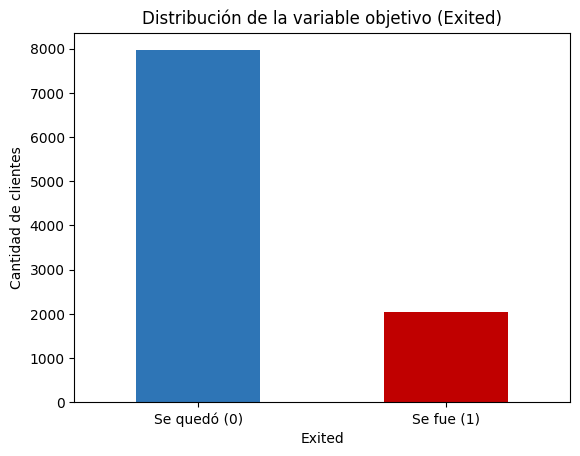

In [29]:
# Aca podemos ver como estan los datos, cual es el balance que hay en el dataset
exited_dist = df["Exited"].value_counts(normalize=True)
print(exited_dist)

# Visualización
df["Exited"].value_counts().plot(kind="bar", color=["#2E75B6", "#C00000"])
plt.title("Distribución de la variable objetivo (Exited)")
plt.xticks([0, 1], ["Se quedó (0)", "Se fue (1)"], rotation=0)
plt.ylabel("Cantidad de clientes")
plt.show()

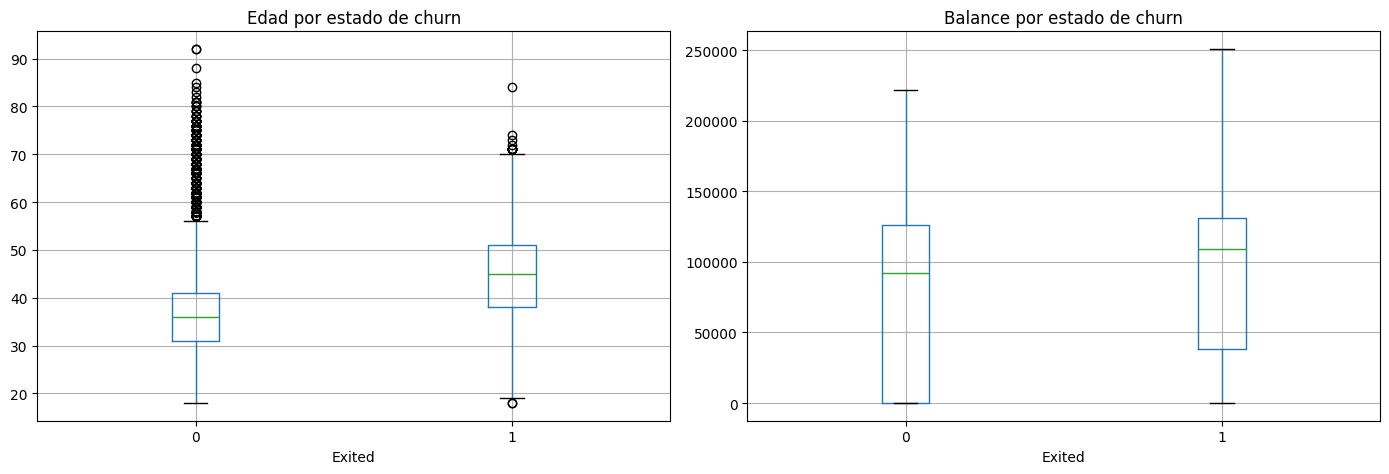

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Edad vs churn
df.boxplot(column="Age", by="Exited", ax=axes[0])
axes[0].set_title("Edad por estado de churn")
axes[0].set_xlabel("Exited")

# Balance vs churn
df.boxplot(column="Balance", by="Exited", ax=axes[1])
axes[1].set_title("Balance por estado de churn")
axes[1].set_xlabel("Exited")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Preparación de los datos

Tenemos que hacer 3 cosas antes de entrenar al modelo
1. **Eliminar columnas inútiles** (que no aportan a la predicción).
2. **Codificar variables categóricas** (texto → números).
3. **Escalar variables numéricas** (KNN es sensible a la escala).

# Eliminar las columnas que no nos sirven

In [31]:
columnas_eliminar = ["RowNumber", "CustomerId", "Surname"]
dfnuevo = df.drop(columns=columnas_eliminar)
print(f"Columnas restantes: {dfnuevo.columns.tolist()}")

Columnas restantes: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Codificar variables

In [32]:
#Variables como Gener y Geography, ya que hay que pasarla de texo a numero
#hay que usar onehotencoder para Geography ya que no hay orden jerarquico entre los paises
# sin embargo, si podemos usar LabelEncoder para Gender ya que, solo tenemos 2 valores

# Gender: LabelEncoder (binario) Female=0, Male=1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dfnuevo["Gender"] = le.fit_transform(dfnuevo["Gender"])
print(f"Visualizacion de Gender: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Visualizacion de Gender: {'Female': np.int64(0), 'Male': np.int64(1)}


In [33]:
#Geography usamos el OneHotEncoder
dfnuevo = pd.get_dummies(dfnuevo, columns = ["Geography"], drop_first=True, dtype=int)
print(f"Columnas restantes: {dfnuevo.columns.tolist()}")
dfnuevo.head()

Columnas restantes: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


##Separar features (X) y objetivo (y)

In [36]:
y = dfnuevo["Exited"]
X = dfnuevo.drop(columns=["Exited"])
print(f"y: {y.shape} - X: {X.shape}")
print(f"X tiene {X.shape[1]} features")
print(f"y tiene {y.shape[0]} etiquetas")

y: (10000,) - X: (10000, 11)
X tiene 11 features
y tiene 10000 etiquetas


##Ahora hacemos el TRAIN/TEST

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17, stratify=y
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Proporción Exited en train: {y_train.mean():.3f}")
print(f"Proporción Exited en test:  {y_test.mean():.3f}")

Train: 7000 filas | Test: 3000 filas
Proporción Exited en train: 0.204
Proporción Exited en test:  0.204


#Escalamiento

In [39]:
from sklearn.preprocessing import StandardScaler

# fit SOLO en train
# transform en test (no fit!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train escalado — primeras filas:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head().round(2))

X_train escalado — primeras filas:
   CreditScore  Gender   Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0        -0.60   -1.09  0.01   -0.71    -1.22           2.49       0.65   
1        -0.73   -1.09  0.01   -0.02     0.67           2.49      -1.54   
2        -2.03    0.92 -0.95    0.32    -1.22          -0.92      -1.54   
3         0.38   -1.09  1.63   -0.02     0.57          -0.92       0.65   
4         0.34    0.92 -0.28   -0.02    -1.22           0.78       0.65   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
0           -1.03             0.70              -0.58             1.74  
1           -1.03            -1.64               1.73            -0.58  
2           -1.03             1.71              -0.58            -0.58  
3            0.97            -0.34               1.73            -0.58  
4            0.97             0.83              -0.58             1.74  


# Vamos a dividir los datos
